In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trainDf = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
testDf = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv")

In [3]:
dtype = trainDf.dtypes
integer_features = dtype[dtype == 'int64']
integer_features

Id               int64
MSSubClass       int64
LotArea          int64
OverallQual      int64
OverallCond      int64
YearBuilt        int64
YearRemodAdd     int64
BsmtFinSF1       int64
BsmtFinSF2       int64
BsmtUnfSF        int64
TotalBsmtSF      int64
1stFlrSF         int64
2ndFlrSF         int64
LowQualFinSF     int64
GrLivArea        int64
BsmtFullBath     int64
BsmtHalfBath     int64
FullBath         int64
HalfBath         int64
BedroomAbvGr     int64
KitchenAbvGr     int64
TotRmsAbvGrd     int64
Fireplaces       int64
GarageCars       int64
GarageArea       int64
WoodDeckSF       int64
OpenPorchSF      int64
EnclosedPorch    int64
3SsnPorch        int64
ScreenPorch      int64
PoolArea         int64
MiscVal          int64
MoSold           int64
YrSold           int64
SalePrice        int64
dtype: object

In [4]:
trainDf.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
with open('/kaggle/input/competitions/home-data-for-ml-course/data_description.txt', 'r') as f:
    data = f.read()

print(data)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [6]:
integer_features_list = dtype[dtype == 'int64'].index.tolist()
integer_features_list

['Id',
 'MSSubClass',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [7]:
intFeaturesDf = trainDf[integer_features_list].drop('Id', axis = 1)
intFeaturesDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 34 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   MSSubClass     1460 non-null   int64
 1   LotArea        1460 non-null   int64
 2   OverallQual    1460 non-null   int64
 3   OverallCond    1460 non-null   int64
 4   YearBuilt      1460 non-null   int64
 5   YearRemodAdd   1460 non-null   int64
 6   BsmtFinSF1     1460 non-null   int64
 7   BsmtFinSF2     1460 non-null   int64
 8   BsmtUnfSF      1460 non-null   int64
 9   TotalBsmtSF    1460 non-null   int64
 10  1stFlrSF       1460 non-null   int64
 11  2ndFlrSF       1460 non-null   int64
 12  LowQualFinSF   1460 non-null   int64
 13  GrLivArea      1460 non-null   int64
 14  BsmtFullBath   1460 non-null   int64
 15  BsmtHalfBath   1460 non-null   int64
 16  FullBath       1460 non-null   int64
 17  HalfBath       1460 non-null   int64
 18  BedroomAbvGr   1460 non-null   int64
 19  Kitche

## Explatory Data Analysis of Integer Type Features

In [8]:
## Finding Correlation

first18list = integer_features_list[1: 18]
first18list.append(integer_features_list[-1])
first18 = intFeaturesDf[first18list]
last18 = intFeaturesDf[integer_features_list[18:-1]]

corr1 = first18.corr()
corr2 = last18.corr()

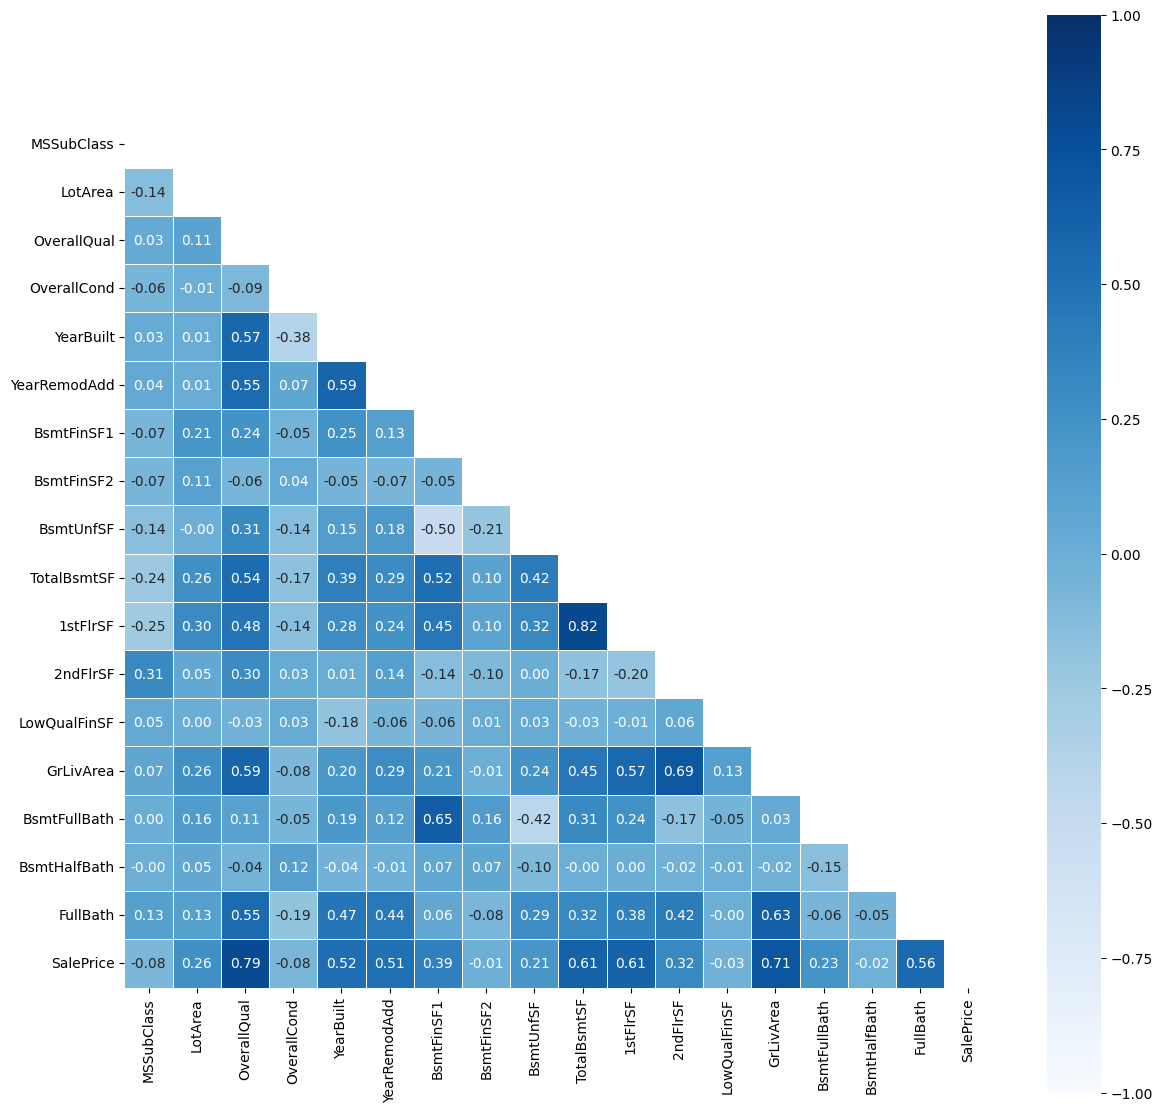

In [9]:
## Plotting HeatMap

plt.figure(figsize = (14, 14))
mask = np.triu(np.ones_like(corr1, dtype=bool))
sns.heatmap(corr1,
           annot = True, 
           cmap = "Blues",
           vmin = -1, 
            vmax = 1, 
           fmt=".2f", square=True, linewidths=.5,
           mask = mask)
plt.show()

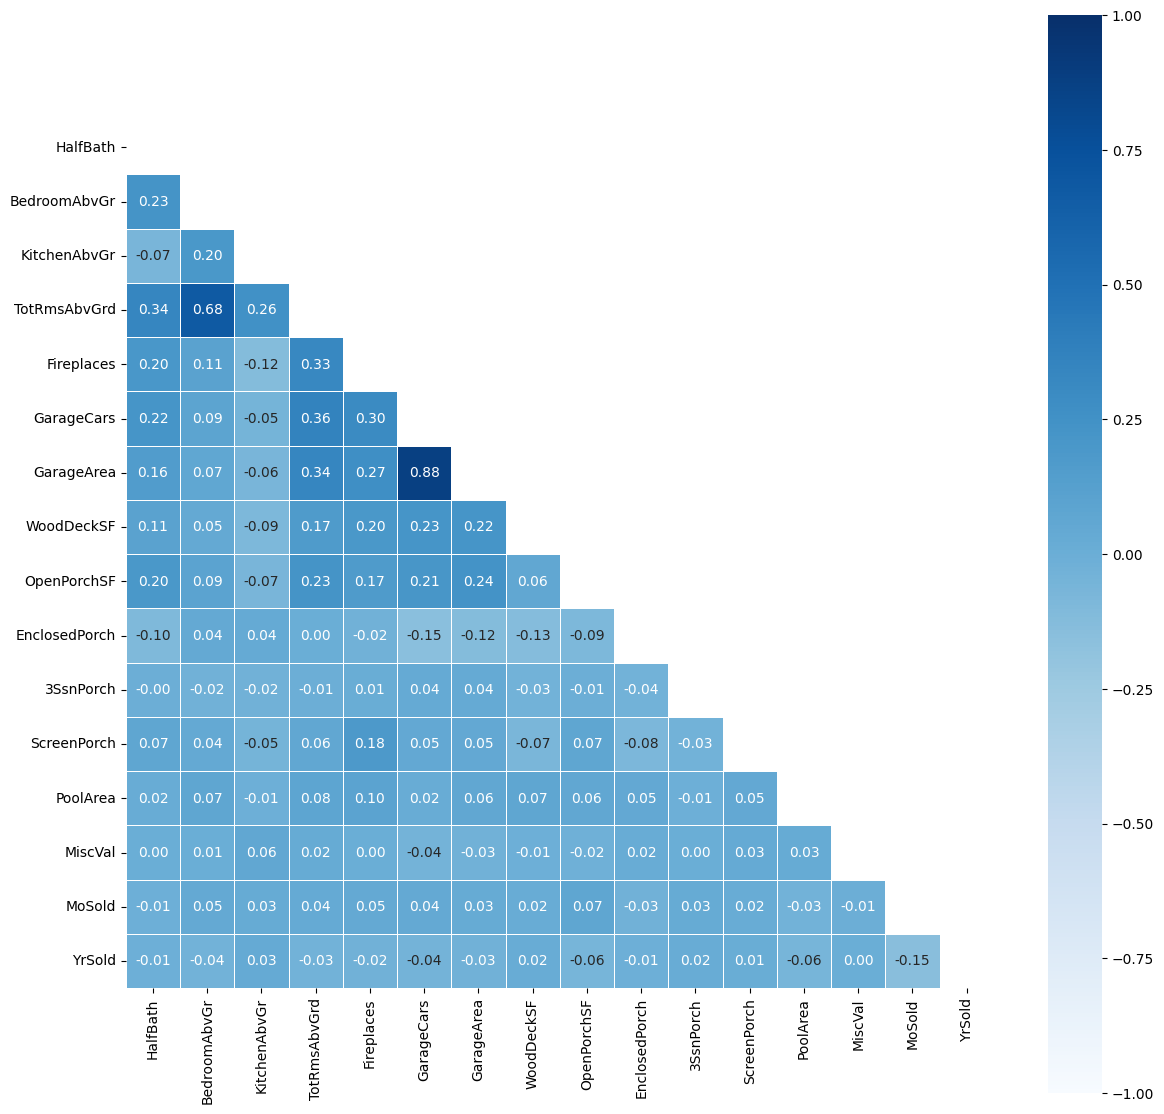

In [10]:
## Plotting HeatMap

plt.figure(figsize = (14, 14))
mask = np.triu(np.ones_like(corr2, dtype=bool))
sns.heatmap(corr2,
           annot = True, 
           cmap = "Blues",
           vmin = -1, 
            vmax = 1, 
           fmt=".2f", square=True, linewidths=.5,
           mask = mask)
plt.show()

In [11]:
## Exploring Overall Quality 

qualList = { 1 : "Very Excellent", 9 : "Excellent", 8 : "Very Good", 7 : "Good", 6 : "Above Average",
           5 : "Average", 4 : "Below Average", 3 : "Fair", 2 : "Poor", 1 : "Very Poor"}

intFeaturesDf["OverallQual"].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

In [12]:
intFeaturesDf["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

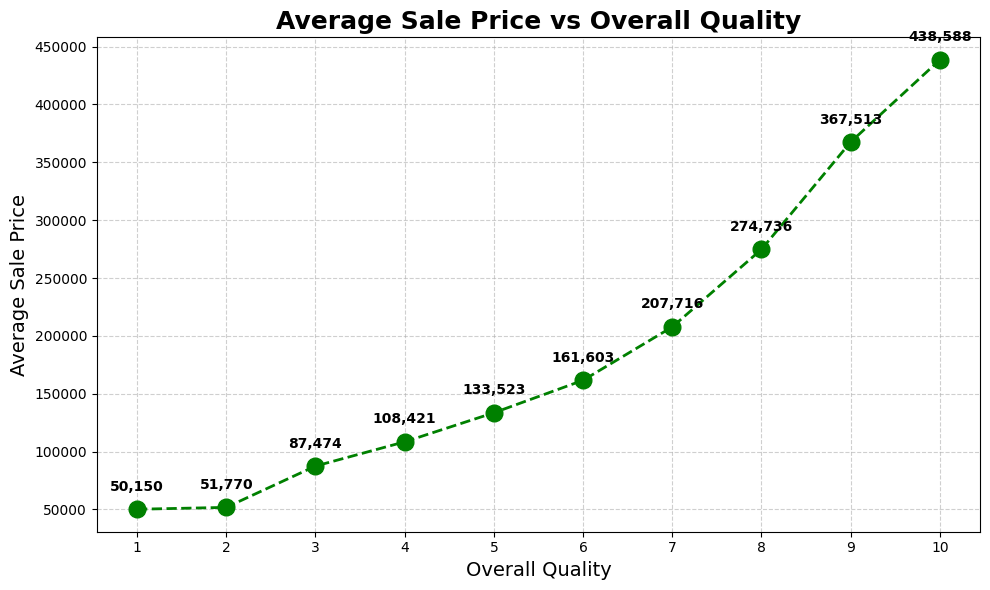

In [13]:
pivotqualList = intFeaturesDf.groupby("OverallQual").mean()

plt.figure(figsize = (10, 6))

plt.plot(pivotqualList.index, pivotqualList["SalePrice"], color='green', marker='o', linestyle='dashed',
         linewidth=2, markersize=12 )
plt.title("Average Sale Price vs Overall Quality", fontsize=18, fontweight='bold')
plt.xlabel("Overall Quality", fontsize=14)
plt.ylabel("Average Sale Price", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

for x, y in zip(pivotqualList.index, pivotqualList["SalePrice"]):
    plt.text(
        x, y + 16000,
        f'{y:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(pivotqualList.index)
plt.tight_layout()

plt.show()

In [14]:
## Number of properties for each 

pivotqualList = intFeaturesDf.groupby("OverallQual").count()
pivotqualList

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
OverallQual,,,,,,,,,,,,,,,,,,,,,
1,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
2,3,3,3,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
3,20,20,20,20,20,20,20,20,20,20,...,20,20,20,20,20,20,20,20,20,20
4,116,116,116,116,116,116,116,116,116,116,...,116,116,116,116,116,116,116,116,116,116
5,397,397,397,397,397,397,397,397,397,397,...,397,397,397,397,397,397,397,397,397,397
6,374,374,374,374,374,374,374,374,374,374,...,374,374,374,374,374,374,374,374,374,374
7,319,319,319,319,319,319,319,319,319,319,...,319,319,319,319,319,319,319,319,319,319
8,168,168,168,168,168,168,168,168,168,168,...,168,168,168,168,168,168,168,168,168,168
9,43,43,43,43,43,43,43,43,43,43,...,43,43,43,43,43,43,43,43,43,43


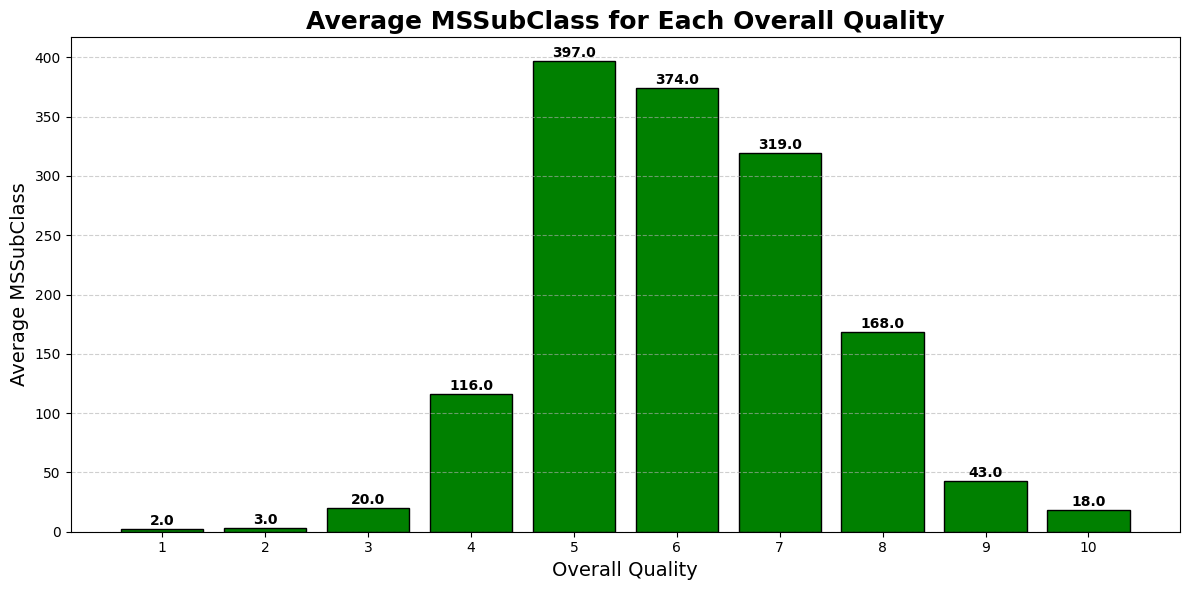

In [15]:
plt.figure(figsize=(12, 6))

plt.bar(
    pivotqualList.index,
    pivotqualList["MSSubClass"],
    color='green',
    edgecolor='black'
)

plt.title(
    "Average MSSubClass for Each Overall Quality",
    fontsize=18,
    fontweight='bold'
)
plt.xlabel("Overall Quality", fontsize=14)
plt.ylabel("Average MSSubClass", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.6)

for x, y in zip(pivotqualList.index, pivotqualList["MSSubClass"]):
    plt.text(
        x,
        y + 1,                  # small offset above bar
        f'{y:.1f}',             # formatted value
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.xticks(pivotqualList.index)
plt.tight_layout()

plt.show()

In [16]:
## Exploring GRLivArea

intFeaturesDf["GrLivArea"].describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

In [17]:
intFeaturesDf['GrLivArea'].head(5)

0    1710
1    1262
2    1786
3    1717
4    2198
Name: GrLivArea, dtype: int64

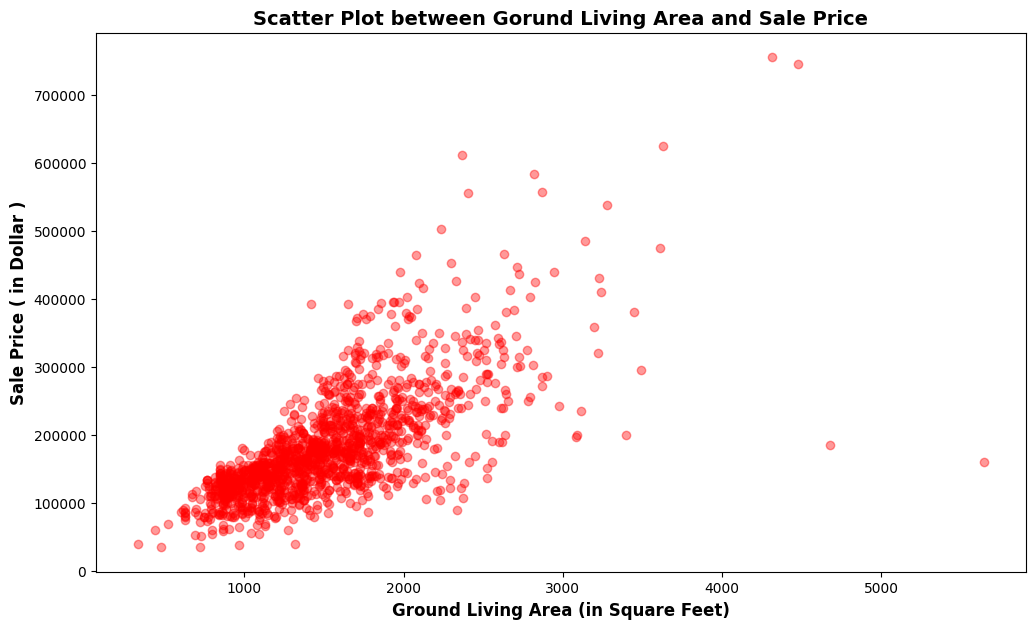

In [18]:
plt.figure(figsize = (12, 7))

plt.scatter(intFeaturesDf["GrLivArea"], intFeaturesDf["SalePrice"], alpha = 0.4, color = 'red')
plt.title("Scatter Plot between Gorund Living Area and Sale Price", fontsize = 14, fontweight = 'bold')
plt.xlabel("Ground Living Area (in Square Feet)", fontsize = 12, fontweight = 'semibold')
plt.ylabel("Sale Price ( in Dollar )", fontsize = 12, fontweight = 'semibold')
plt.show()

In [19]:
low_price = intFeaturesDf[
    (intFeaturesDf["GrLivArea"] > 4000) &
    (intFeaturesDf["SalePrice"] < 300000)
]

high_price = intFeaturesDf[
    (intFeaturesDf["GrLivArea"] > 4000) &
    (intFeaturesDf["SalePrice"] >= 300000)
]

comparison = pd.concat(
    [low_price.T, high_price.T],
    axis=1,
    keys=["Low Price Houses", "High Price Houses"]
)

comparison

Low Price Houses         High Price Houses        
                          523     1298              691     1182
MSSubClass                  60      60                60      60
LotArea                  40094   63887             21535   15623
OverallQual                 10      10                10      10
OverallCond                  5       5                 6       5
YearBuilt                 2007    2008              1994    1996
YearRemodAdd              2008    2008              1995    1996
BsmtFinSF1                2260    5644              1455    2096
BsmtFinSF2                   0       0                 0       0
BsmtUnfSF                  878     466               989     300
TotalBsmtSF               3138    6110              2444    2396
1stFlrSF                  3138    4692              2444    2411
2ndFlrSF                  1538     950              1872    2065
LowQualFinSF                 0       0                 0       0
GrLivArea                 4676    5642              4316    4476
BsmtFullBath                 1       2                 0       1
BsmtHalfBath                 0       0                 1       0
FullBath                     3       2                 3       3
HalfBath                     1       1                 1       1
BedroomAbvGr                 3       3                 4       4
KitchenAbvGr                 1       1                 1       1
TotRmsAbvGrd                11      12                10      10
Fireplaces                   1       3                 2       2
GarageCars                   3       2                 3       3
GarageArea                 884    1418               832     813
WoodDeckSF                 208     214               382     171
OpenPorchSF                406     292                50      78
EnclosedPorch                0       0                 0       0
3SsnPorch                    0       0                 0       0
ScreenPorch                  0       0                 0       0
PoolArea                     0     480                 0     555
MiscVal                      0       0                 0       0
MoSold                      10       1                 1       7
YrSold                    2007    2008              2007    2007
SalePrice               184750  160000            755000  745000

In [20]:
intFeaturesDf["TotalBsmtSF"].describe()

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

/tmp/ipykernel_57/544212390.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bsmt_price = ( intFeaturesDf.groupby("BsmtBins")["SalePrice"].mean())


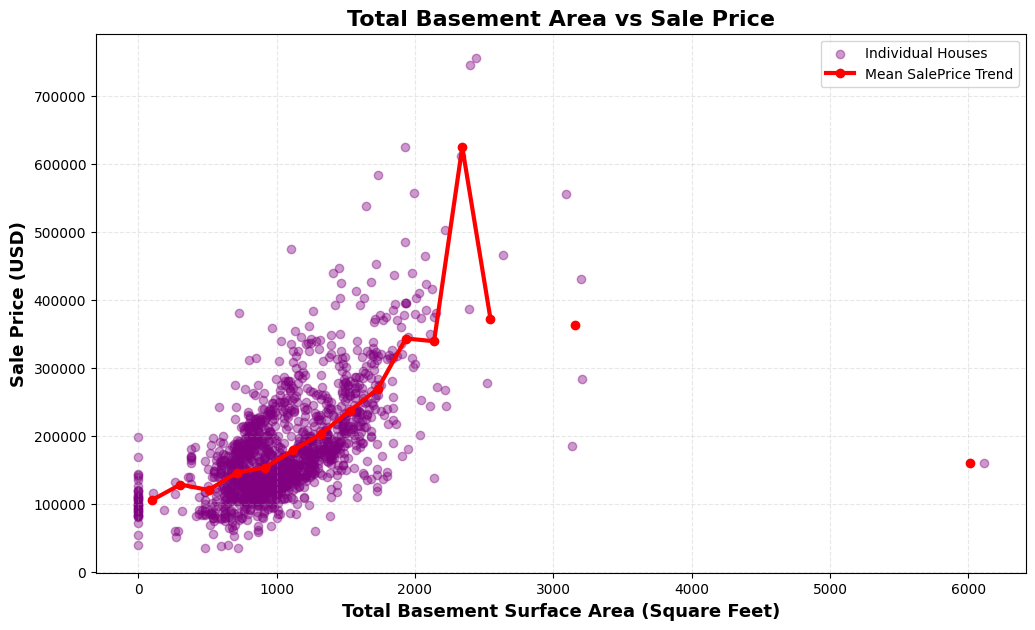

In [21]:
intFeaturesDf["BsmtBins"] = pd.cut( intFeaturesDf["TotalBsmtSF"], bins=30 )
mean_bsmt_price = ( intFeaturesDf.groupby("BsmtBins")["SalePrice"].mean())

bin_centers = [
    interval.mid for interval in mean_bsmt_price.index
]

plt.figure(figsize=(12, 7))
plt.scatter( intFeaturesDf["TotalBsmtSF"], intFeaturesDf["SalePrice"], alpha=0.4,
    color='purple', label='Individual Houses'
)
plt.plot(
    bin_centers, mean_bsmt_price.values, color='red',
    linewidth=3, marker='o', label='Mean SalePrice Trend'
)

plt.title(
    "Total Basement Area vs Sale Price", fontsize=16, fontweight='bold'
)

plt.xlabel(
    "Total Basement Surface Area (Square Feet)", fontsize=13, fontweight='semibold'
)

plt.ylabel(
    "Sale Price (USD)", fontsize=13, fontweight='semibold'
)

plt.grid(alpha=0.3, linestyle='--')
plt.legend()

plt.show()

In [22]:
intFeaturesDf[intFeaturesDf["TotalBsmtSF"] > 4000].T

,1298
MSSubClass,60
LotArea,63887
OverallQual,10
OverallCond,5
YearBuilt,2008
YearRemodAdd,2008
BsmtFinSF1,5644
BsmtFinSF2,0
BsmtUnfSF,466
TotalBsmtSF,6110


/tmp/ipykernel_57/1361380032.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_bsmt_price = ( intFeaturesDf.groupby("BsmtBins")["SalePrice"].mean())


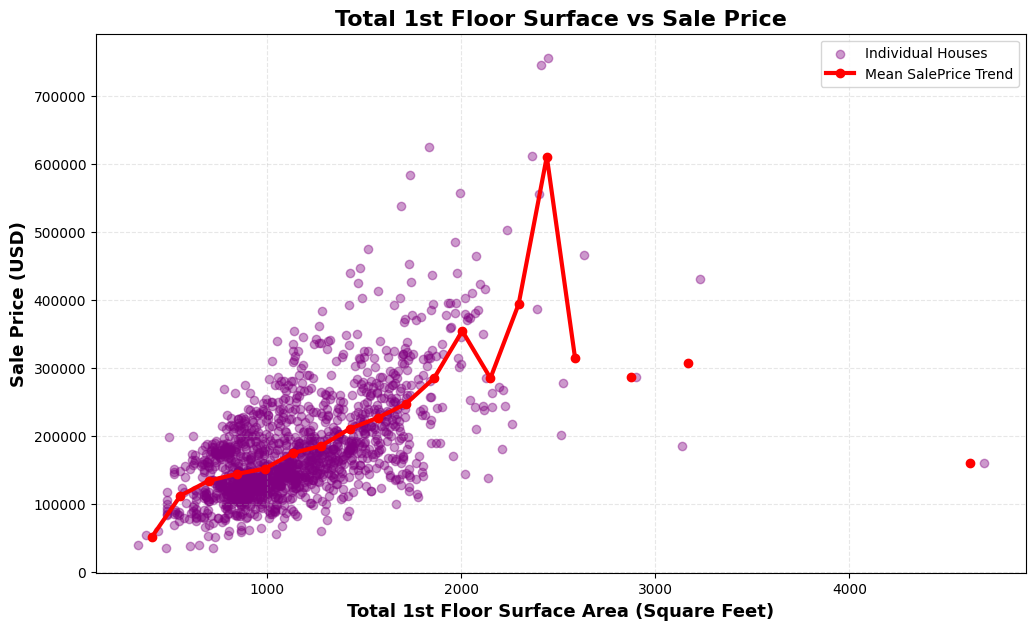

In [23]:
intFeaturesDf["BsmtBins"] = pd.cut( intFeaturesDf["1stFlrSF"], bins=30 )
mean_bsmt_price = ( intFeaturesDf.groupby("BsmtBins")["SalePrice"].mean())

bin_centers = [
    interval.mid for interval in mean_bsmt_price.index
]

plt.figure(figsize=(12, 7))
plt.scatter( intFeaturesDf["1stFlrSF"], intFeaturesDf["SalePrice"], alpha=0.4,
    color='purple', label='Individual Houses'
)
plt.plot(
    bin_centers, mean_bsmt_price.values, color='red',
    linewidth=3, marker='o', label='Mean SalePrice Trend'
)

plt.title(
    "Total 1st Floor Surface vs Sale Price", fontsize=16, fontweight='bold'
)

plt.xlabel(
    "Total 1st Floor Surface Area (Square Feet)", fontsize=13, fontweight='semibold'
)

plt.ylabel(
    "Sale Price (USD)", fontsize=13, fontweight='semibold'
)

plt.grid(alpha=0.3, linestyle='--')
plt.legend()

plt.show()

In [24]:
intFeaturesDf["YearBuilt"].describe()

count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

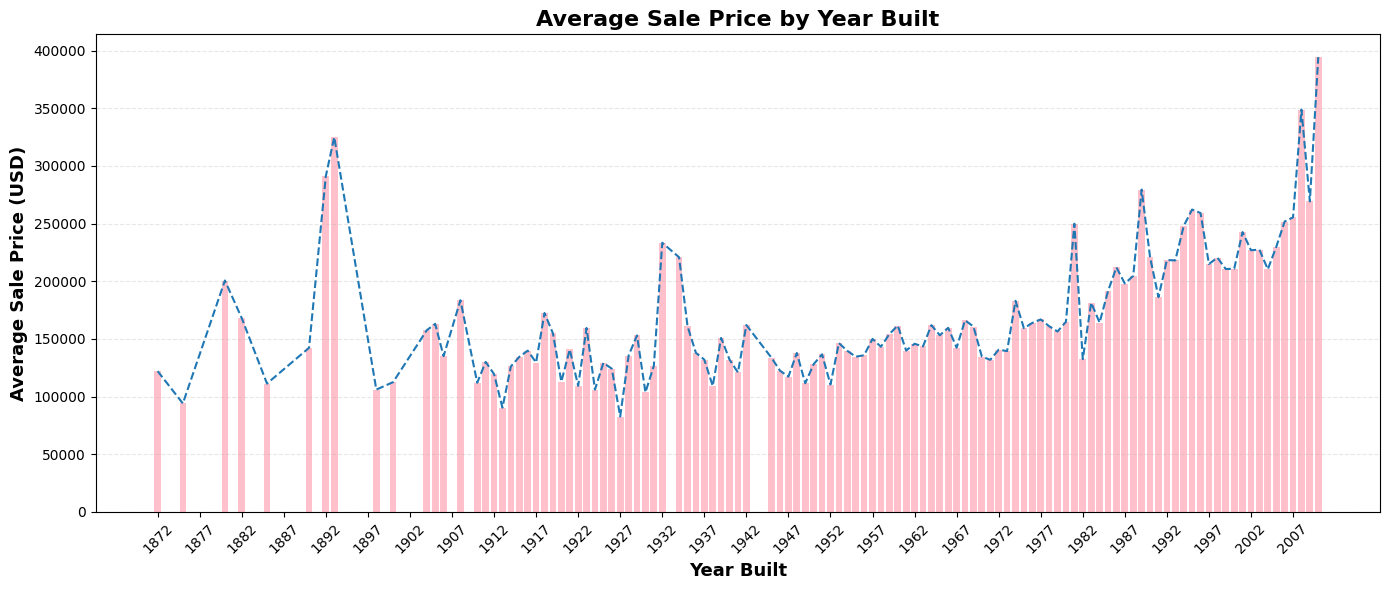

In [25]:
grp_df = intFeaturesDf.groupby("YearBuilt")["SalePrice"].mean()

plt.figure(figsize=(14, 6))

plt.bar( grp_df.index, grp_df.values, color='pink')
plt.plot(grp_df.index, grp_df.values, linestyle = "--")
plt.title( "Average Sale Price by Year Built", fontsize=16, fontweight='bold' )
plt.xlabel( "Year Built", fontsize=13, fontweight='semibold' )
plt.ylabel( "Average Sale Price (USD)", fontsize=13, fontweight='semibold' )

# X-ticks every 5 years
plt.xticks(range( int(grp_df.index.min()), int(grp_df.index.max()) + 1, 5), rotation=45 )
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

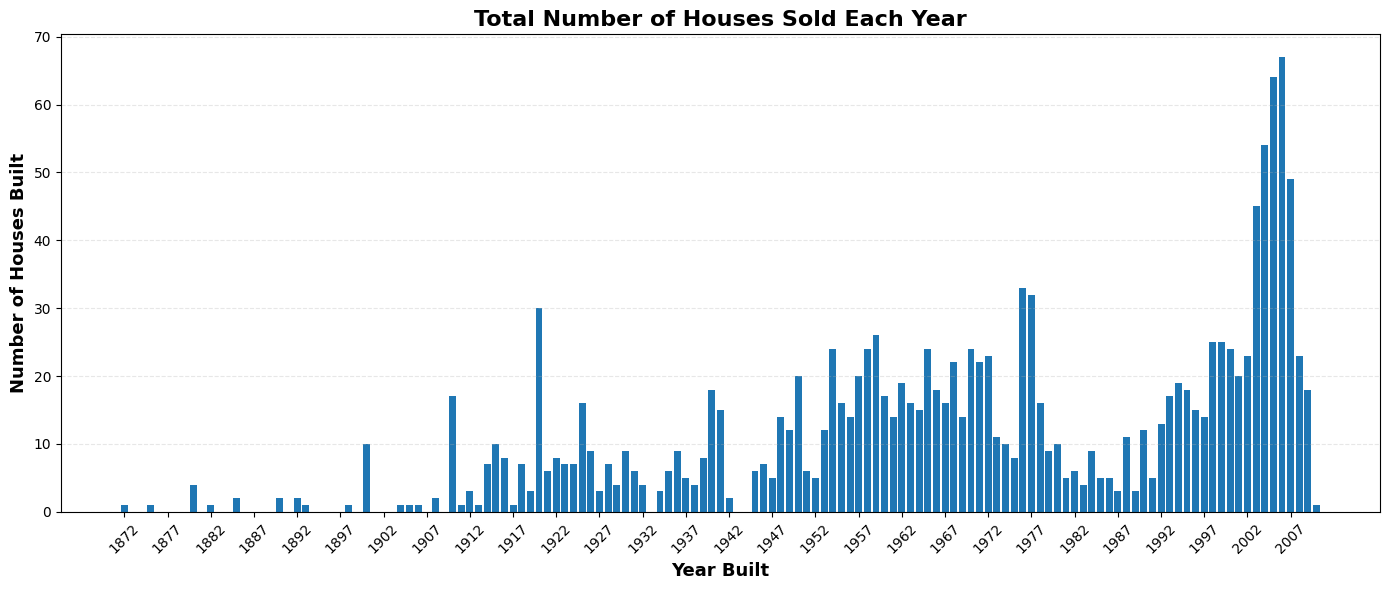

In [26]:
houses_sold_per_year = intFeaturesDf["YearBuilt"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.bar( houses_sold_per_year.index, houses_sold_per_year.values )
plt.title( "Total Number of Houses Sold Each Year", fontsize=16, fontweight='bold' )
plt.xlabel( "Year Built", fontsize=13, fontweight='semibold' )
plt.ylabel( "Number of Houses Built", fontsize=13, fontweight='semibold' )

plt.xticks(range( int(grp_df.index.min()), int(grp_df.index.max()) + 1, 5), rotation = 45)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [27]:
intFeaturesDf["YrSold"].describe()

count    1460.000000
mean     2007.815753
std         1.328095
min      2006.000000
25%      2007.000000
50%      2008.000000
75%      2009.000000
max      2010.000000
Name: YrSold, dtype: float64

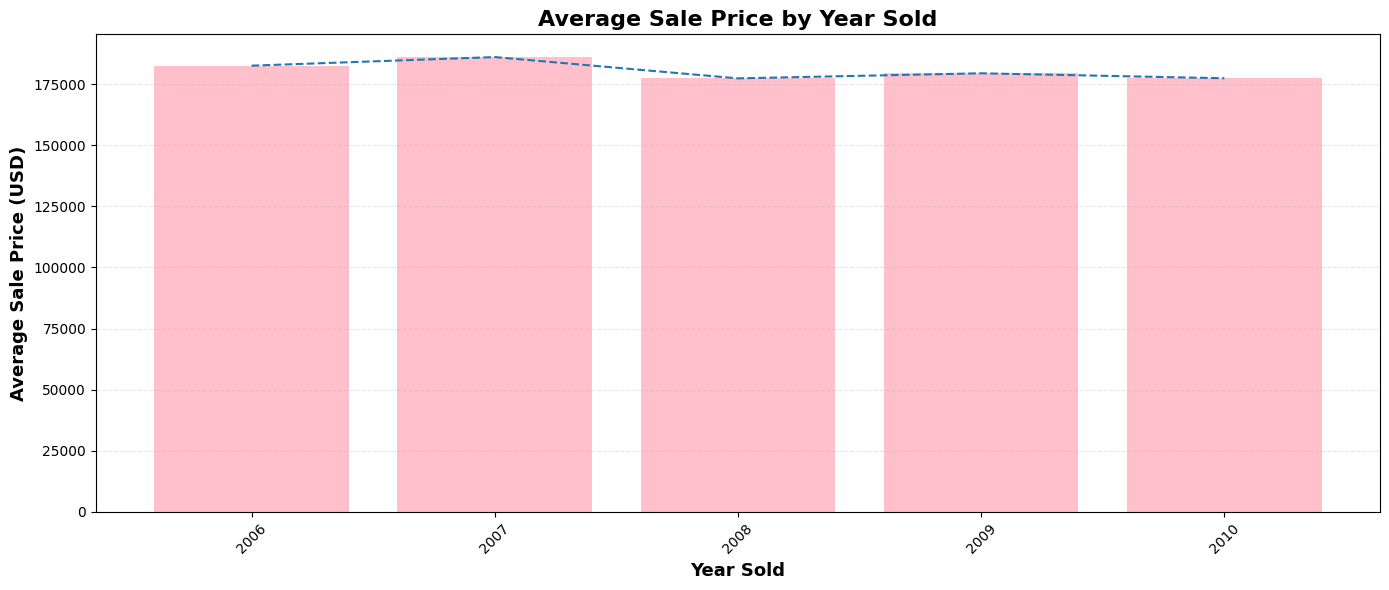

In [28]:
grp_df = intFeaturesDf.groupby("YrSold")["SalePrice"].mean()

plt.figure(figsize=(14, 6))

plt.bar( grp_df.index, grp_df.values, color='pink')
plt.plot(grp_df.index, grp_df.values, linestyle = "--")
plt.title( "Average Sale Price by Year Sold", fontsize=16, fontweight='bold' )
plt.xlabel( "Year Sold", fontsize=13, fontweight='semibold' )
plt.ylabel( "Average Sale Price (USD)", fontsize=13, fontweight='semibold' )

# X-ticks every 5 years
plt.xticks(grp_df.index, rotation=45 )
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

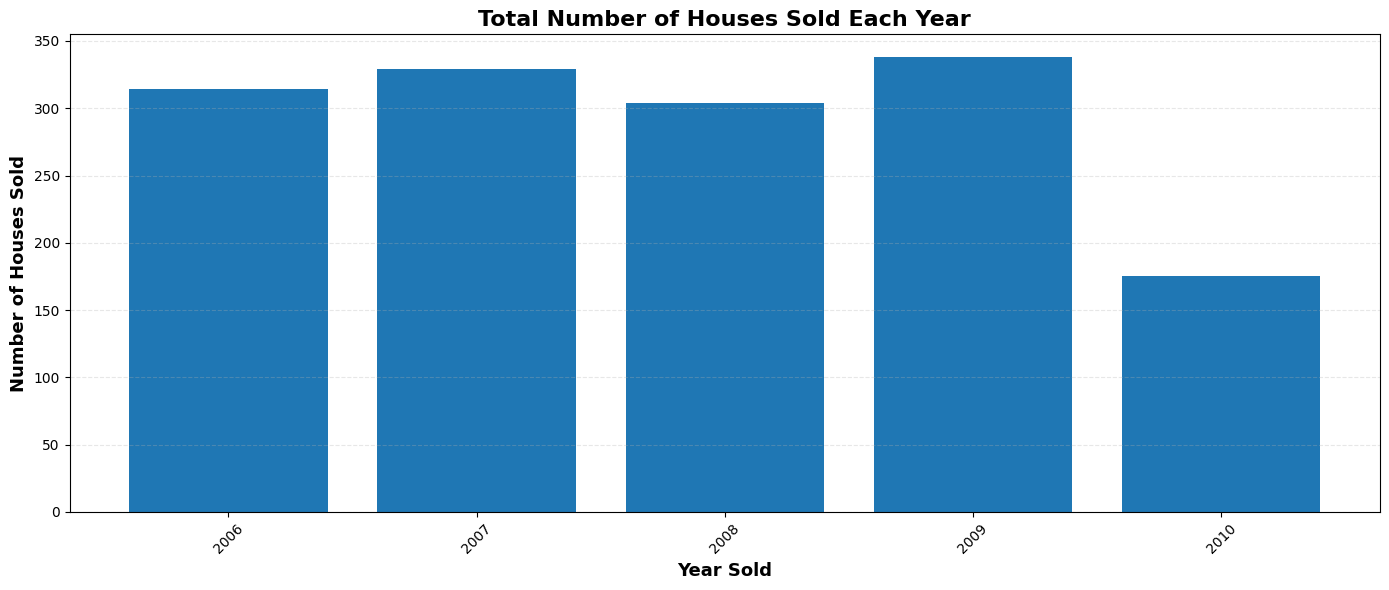

In [29]:
houses_sold_per_year = intFeaturesDf["YrSold"].value_counts().sort_index()

plt.figure(figsize=(14, 6))

plt.bar( houses_sold_per_year.index, houses_sold_per_year.values )
plt.title( "Total Number of Houses Sold Each Year", fontsize=16, fontweight='bold' )
plt.xlabel( "Year Sold", fontsize=13, fontweight='semibold' )
plt.ylabel( "Number of Houses Sold", fontsize=13, fontweight='semibold' )

plt.xticks(houses_sold_per_year.index, rotation = 45)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

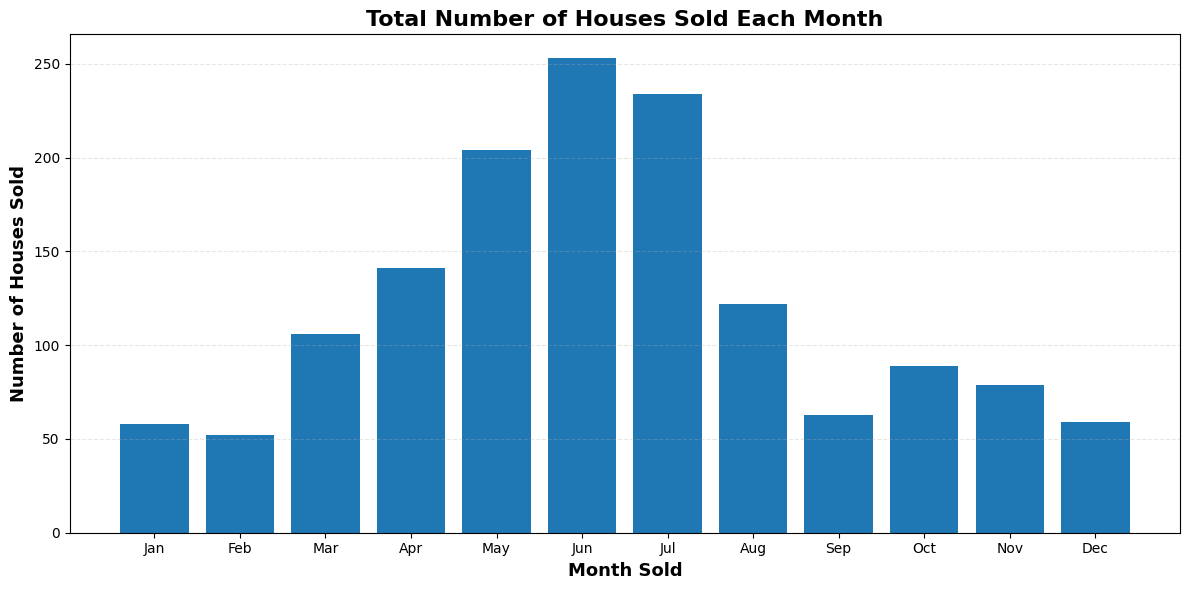

In [30]:
houses_sold_per_month = intFeaturesDf["MoSold"].value_counts().sort_index()

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 6))

plt.bar( houses_sold_per_month.index, houses_sold_per_month.values )

plt.title( "Total Number of Houses Sold Each Month", fontsize=16, fontweight='bold' )

plt.xlabel( "Month Sold", fontsize=13, fontweight='semibold' )
plt.ylabel( "Number of Houses Sold", fontsize=13, fontweight='semibold' )

plt.xticks(
    ticks=range(1, 13),
    labels=month_names
)

plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()

plt.show()

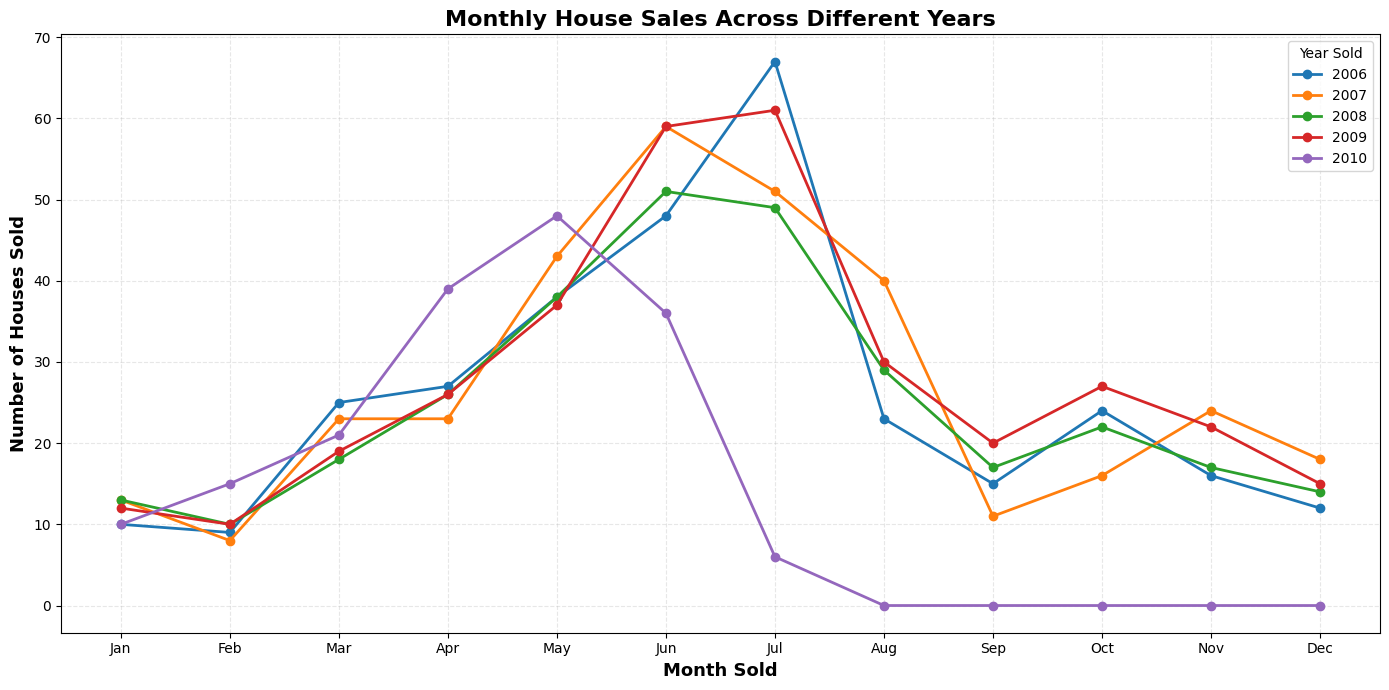

In [31]:
monthly_sales = ( intFeaturesDf.groupby(["YrSold", "MoSold"]).size().unstack(fill_value=0))

month_names = [ "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec" ]

plt.figure(figsize=(14, 7))

for year in monthly_sales.index:
    plt.plot( monthly_sales.columns, monthly_sales.loc[year], marker='o', linewidth=2, label=year )

plt.title( "Monthly House Sales Across Different Years", fontsize=16, fontweight='bold' )

plt.xlabel( "Month Sold", fontsize=13, fontweight='semibold' )
plt.ylabel( "Number of Houses Sold", fontsize=13, fontweight='semibold' )
plt.xticks( ticks=range(1, 13), labels=month_names )
plt.grid(alpha=0.3, linestyle='--')
plt.legend(title="Year Sold")
plt.tight_layout()

plt.show()

In [32]:
trainDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [33]:
dtype = trainDf.dtypes
float_features = dtype[dtype == 'float64']
float_features

LotFrontage    float64
MasVnrArea     float64
GarageYrBlt    float64
dtype: object

In [34]:
float_features = trainDf.select_dtypes(include=['float64'])

corr_with_saleprice = trainDf[float_features.columns.tolist() + ["SalePrice"]].corr()

corr_with_saleprice

,LotFrontage,MasVnrArea,GarageYrBlt,SalePrice
LotFrontage,1.000000,0.193458,0.070250,0.351799
MasVnrArea,0.193458,1.000000,0.252691,0.477493
GarageYrBlt,0.070250,0.252691,1.000000,0.486362
SalePrice,0.351799,0.477493,0.486362,1.000000


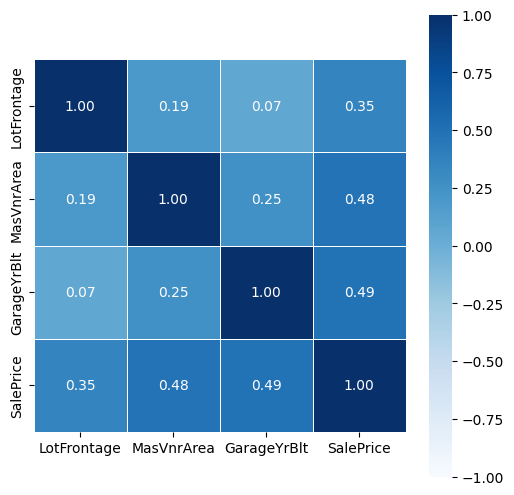

In [35]:
plt.figure(figsize = (6, 6))
sns.heatmap(corr_with_saleprice, annot = True, cmap = "Blues", vmin = -1,  vmax = 1, fmt=".2f", square=True, linewidths=.5)
plt.show()

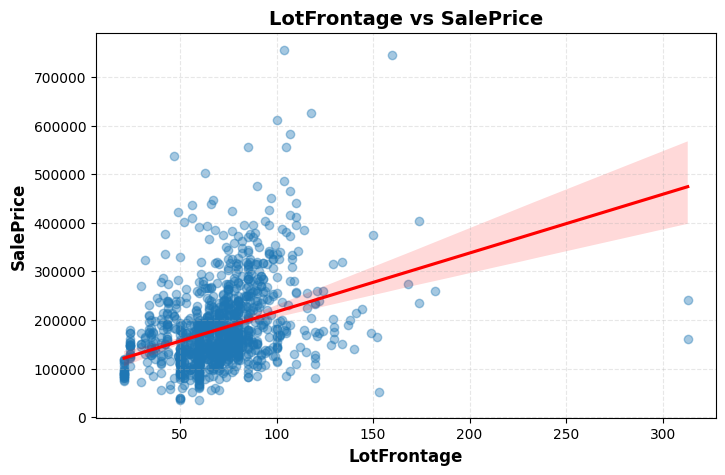

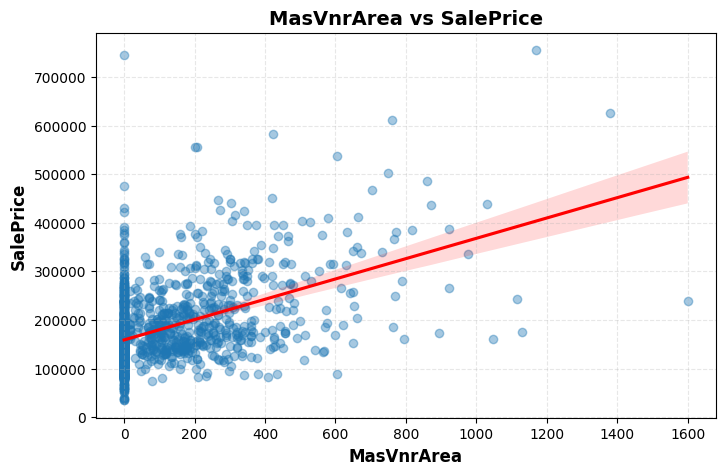

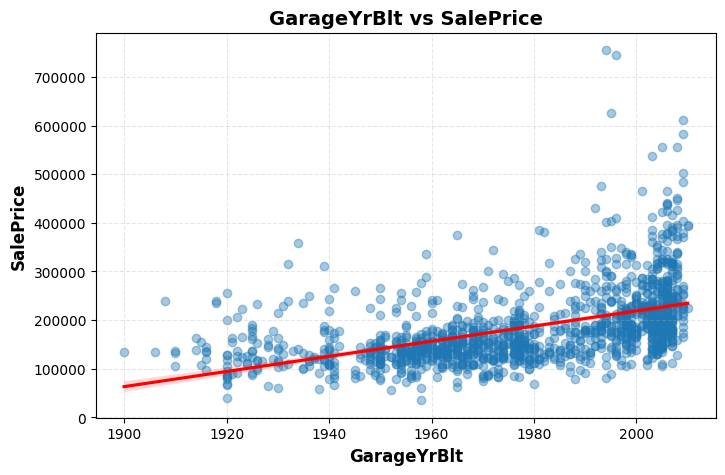

In [36]:
float_cols = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]

for col in float_cols:

    plt.figure(figsize=(8, 5))
    sns.regplot( x=trainDf[col], y=trainDf["SalePrice"], scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
    plt.title( f"{col} vs SalePrice", fontsize=14, fontweight='bold' )
    plt.xlabel( col, fontsize=12, fontweight='semibold' )
    plt.ylabel( "SalePrice", fontsize=12, fontweight='semibold' )
    plt.grid(alpha=0.3, linestyle='--')

    plt.show()

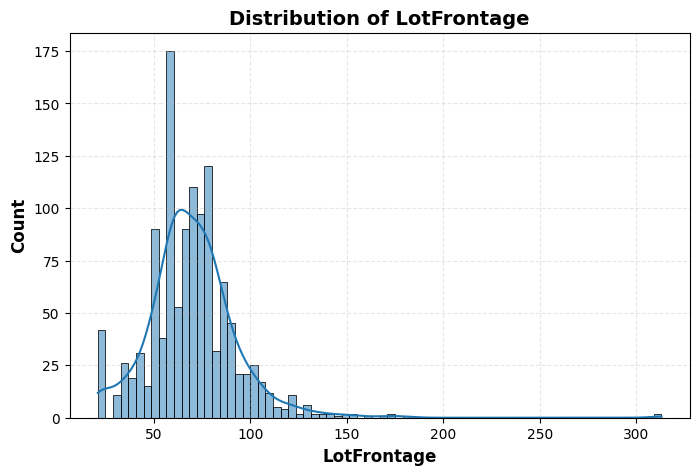

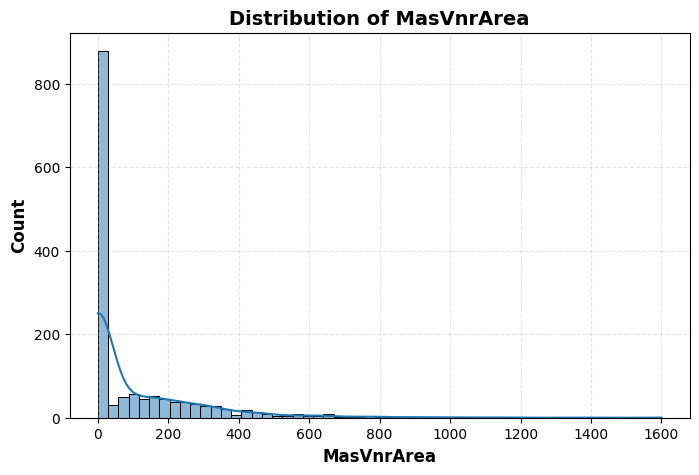

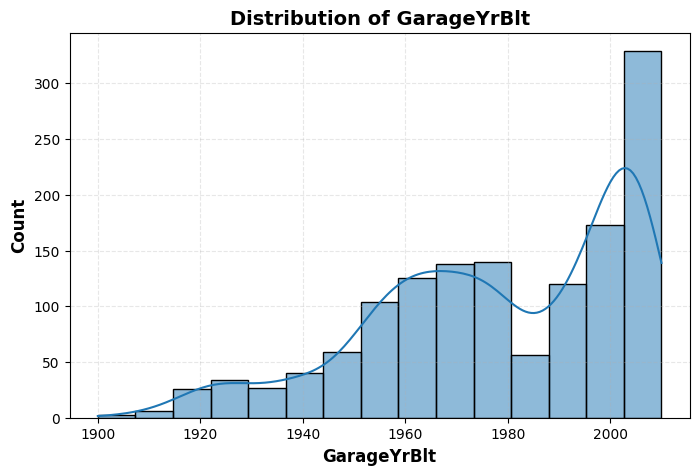

In [37]:
float_cols = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]

for col in float_cols:

    plt.figure(figsize=(8, 5))
    sns.histplot( trainDf[col], kde=True )
    plt.title( f"Distribution of {col}", fontsize=14, fontweight='bold' )
    plt.xlabel( col, fontsize=12, fontweight='semibold' )
    plt.ylabel( "Count", fontsize=12, fontweight='semibold')
    plt.grid(alpha=0.3, linestyle='--')

    plt.show()

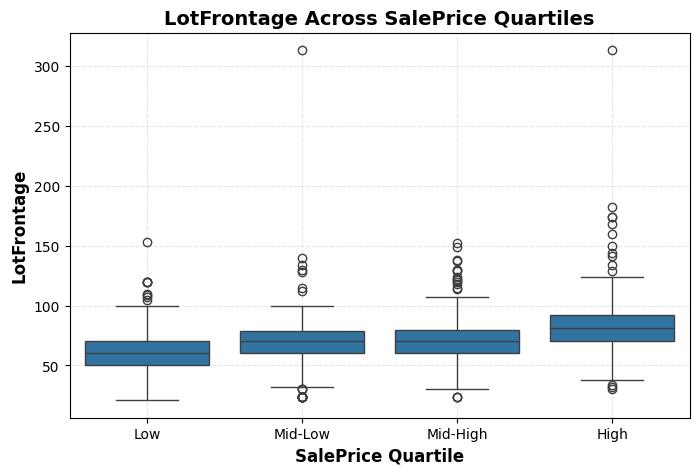

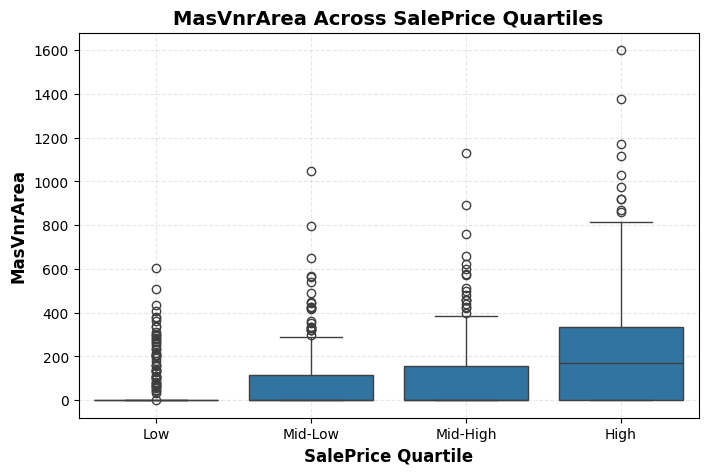

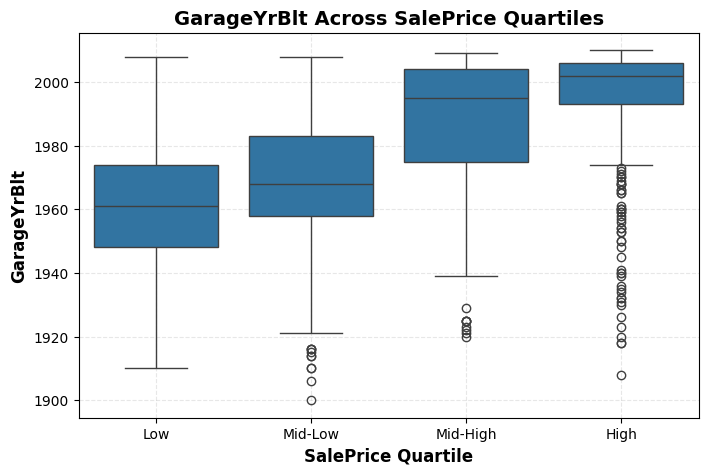

In [38]:
trainDf["PriceQuartile"] = pd.qcut( trainDf["SalePrice"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"] )

float_cols = ["LotFrontage", "MasVnrArea", "GarageYrBlt"]

for col in float_cols:

    plt.figure(figsize=(8, 5))
    sns.boxplot( x="PriceQuartile", y=col, data=trainDf)
    plt.title( f"{col} Across SalePrice Quartiles", fontsize=14, fontweight='bold' )
    plt.xlabel( "SalePrice Quartile", fontsize=12, fontweight='semibold' )

    plt.ylabel( col, fontsize=12, fontweight='semibold' )
    plt.grid(alpha=0.3, linestyle='--')

    plt.show()

In [39]:
obj_cols = trainDf.select_dtypes(include=['object']).columns

print(f"Total Object Columns: {len(obj_cols)}")
print(obj_cols.tolist())

Total Object Columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


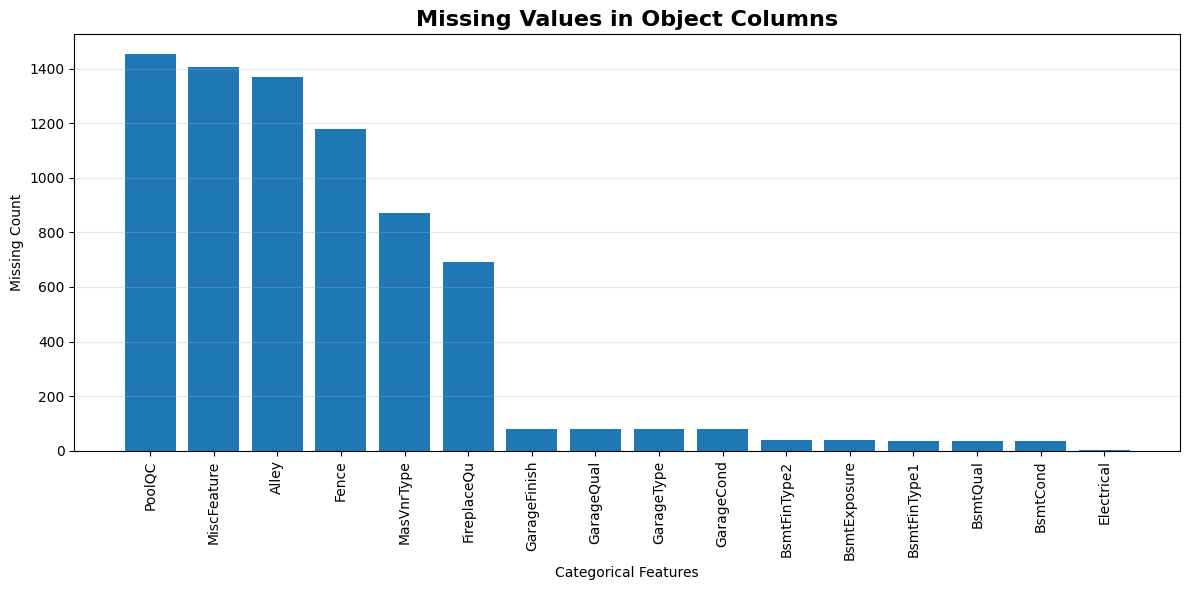

In [40]:
missing_obj = ( trainDf[obj_cols].isnull().sum().sort_values(ascending=False))

missing_obj = missing_obj[missing_obj > 0]

plt.figure(figsize=(12, 6))

plt.bar( missing_obj.index, missing_obj.values )

plt.title( "Missing Values in Object Columns", fontsize=16, fontweight='bold' )
plt.xlabel("Categorical Features")
plt.ylabel("Missing Count")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

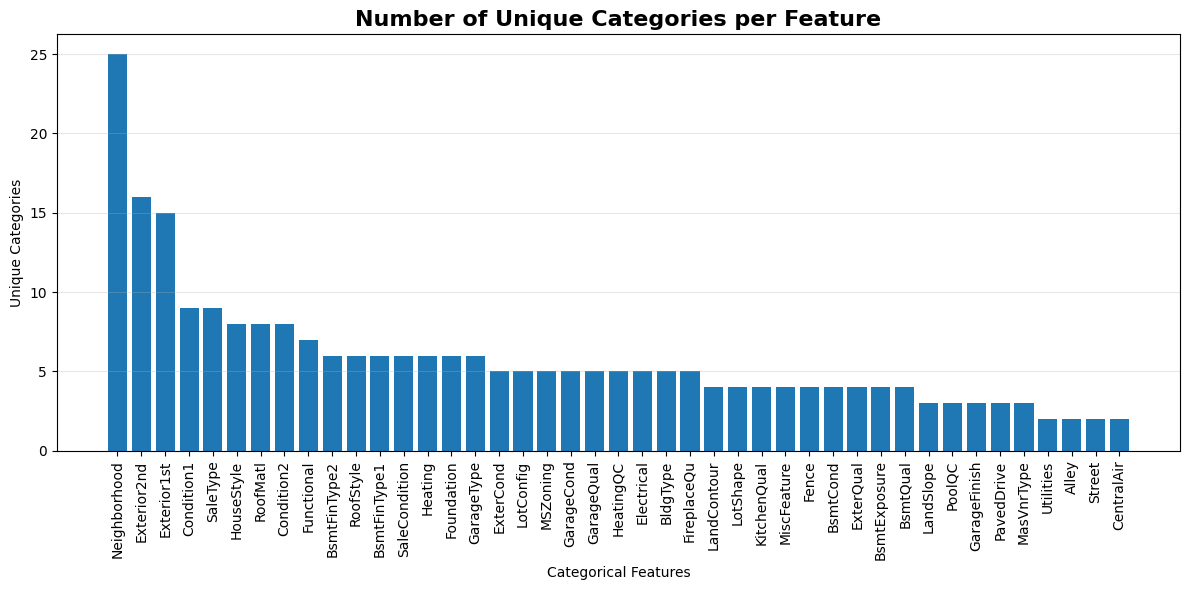

In [41]:
cardinality = trainDf[obj_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.bar( cardinality.index, cardinality.values )

plt.title( "Number of Unique Categories per Feature", fontsize=16, fontweight='bold' )
plt.xlabel("Categorical Features")
plt.ylabel("Unique Categories")
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

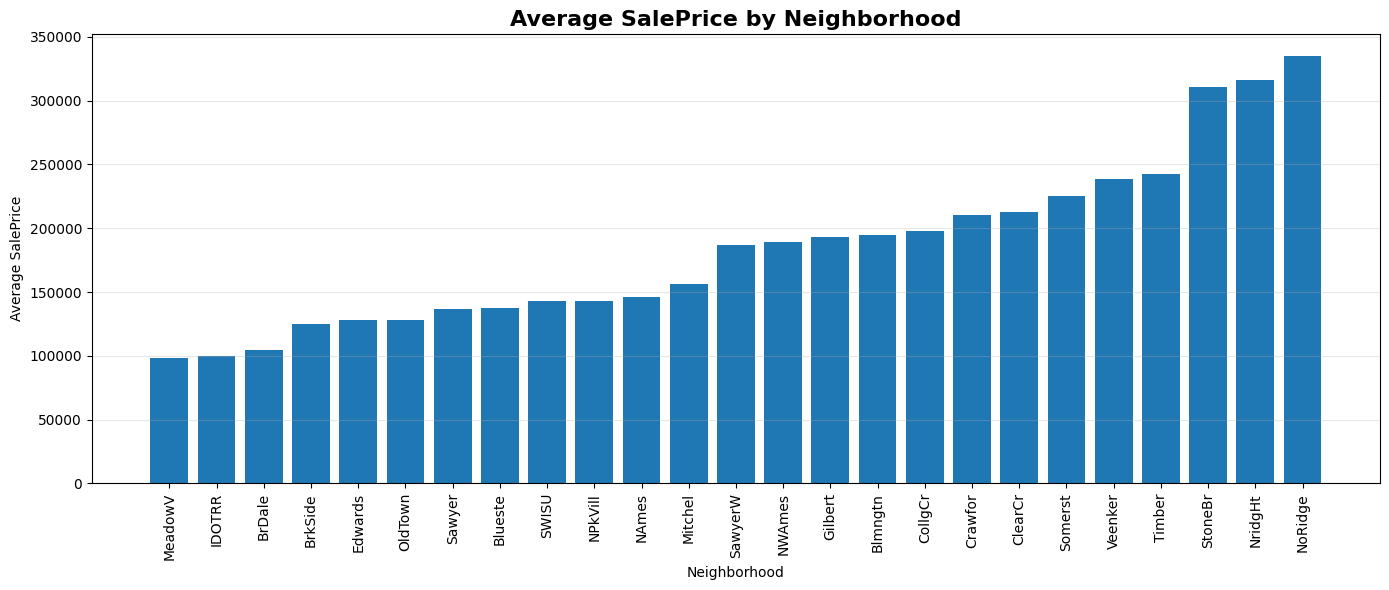

In [42]:
plt.figure(figsize=(14, 6))

avg_price = ( trainDf.groupby("Neighborhood")["SalePrice"].mean().sort_values() )
plt.bar( avg_price.index, avg_price.values )
plt.title( "Average SalePrice by Neighborhood", fontsize=16, fontweight='bold')

plt.xlabel("Neighborhood")
plt.ylabel("Average SalePrice")

plt.xticks(rotation=90)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

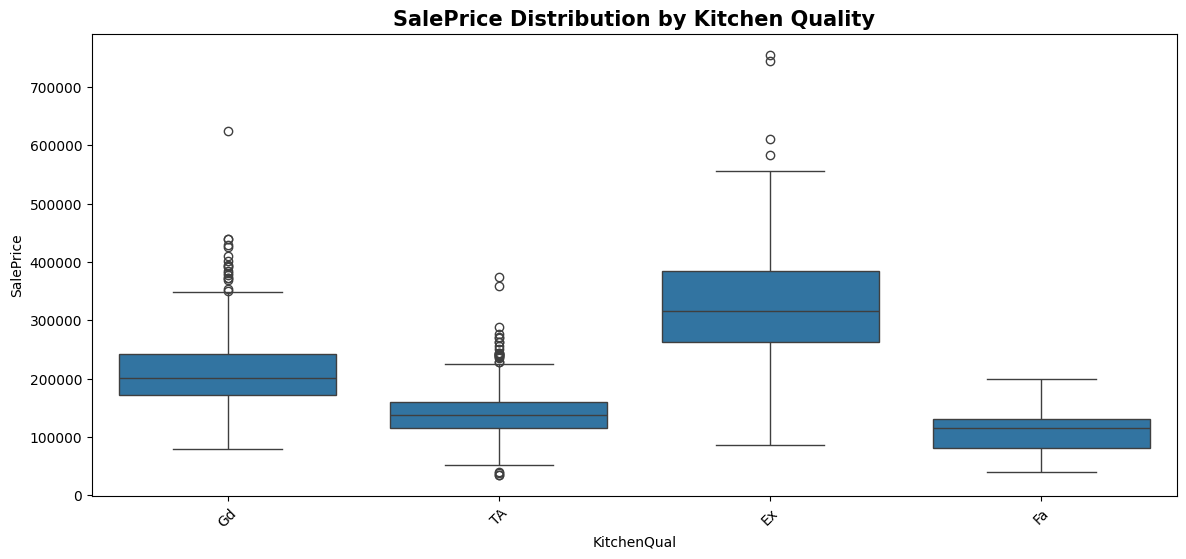

In [43]:
plt.figure(figsize=(14, 6))

sns.boxplot( x="KitchenQual", y="SalePrice", data=trainDf )

plt.title( "SalePrice Distribution by Kitchen Quality", fontsize=15, fontweight='bold' )
plt.xticks(rotation=45)
plt.show()

In [44]:
pd.crosstab(
    trainDf["Neighborhood"],
    trainDf["OverallQual"]
)

OverallQual,1,2,3,4,5,6,7,8,9,10
Neighborhood,,,,,,,,,,
Blmngtn,0,0,0,0,0,0,14,3,0,0
Blueste,0,0,0,0,0,2,0,0,0,0
BrDale,0,0,0,0,5,11,0,0,0,0
BrkSide,1,1,3,10,21,18,4,0,0,0
ClearCr,0,0,0,3,6,10,9,0,0,0
CollgCr,0,0,0,1,28,24,71,23,3,0
Crawfor,0,0,0,1,11,19,13,7,0,0
Edwards,1,0,5,25,38,23,5,0,1,2
Gilbert,0,0,0,1,3,33,36,5,1,0


In [57]:
trainDf = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
testDf = pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv")

In [58]:
for df in [trainDf, testDf]:

    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

    df["TotalBath"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["3SsnPorch"]
        + df["EnclosedPorch"]
        + df["ScreenPorch"]
        + df["WoodDeckSF"]
    )

    df["TotalQuality"] = df["OverallQual"] + df["OverallCond"]

In [59]:
for df in [trainDf, testDf]:

    num_cols = df.select_dtypes(include=["int64", "float64"]).columns

    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    obj_cols = df.select_dtypes(include=["object"]).columns

    for col in obj_cols:
        df[col] = df[col].fillna("None")

In [60]:
trainDf["SalePrice"] = np.log1p(trainDf["SalePrice"])

In [61]:
y_train = trainDf["SalePrice"]

In [62]:
train_features = trainDf.drop("SalePrice", axis=1)

In [63]:
train_features = pd.get_dummies(train_features, drop_first=True)
testDf = pd.get_dummies(testDf, drop_first=True)

In [64]:
train_features, testDf = train_features.align(
    testDf,
    join="left",
    axis=1,
    fill_value=0
)

In [65]:
X_train = train_features.drop("Id", axis=1)
X_test = testDf.drop("Id", axis=1)

In [66]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
xgb_preds = xgb_model.predict(X_test)
final_preds = np.expm1(xgb_preds)

In [68]:
submission = pd.DataFrame({
    "Id": testDf["Id"],
    "SalePrice": final_preds
})

submission.to_csv("submission.csv", index=False)
print(submission.head())

     Id      SalePrice
0  1461  123846.429688
1  1462  159641.000000
2  1463  181826.046875
3  1464  195204.375000
4  1465  185693.093750
